In [ ]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as ss
import seaborn as sns
from tqdm import tqdm

import torch
import torch_geometric
from torch_geometric.loader import DataLoader

# set figure parameters
sc.settings.set_figure_params(dpi=100)

In [2]:
from celcomen.models.celcomen import celcomen
from celcomen.models.simcomen import simcomen
from celcomen.training_plan.train import train
from celcomen.utils.helpers import calc_gex, get_pos, get_pos, calc_sphex, normalize_g2g

In [3]:
from torch_geometric.loader import DataLoader
import scanpy as sc
import torch
import torch_geometric
#from torch_cluster.knn import knn_graph
from sklearn.neighbors import kneighbors_graph
import numpy as np

from scipy.spatial.distance import pdist, squareform

def get_dataset_loaders(h5ad_path: str, sample_id_name: str, n_neighbors: int, device: str, verbose: bool):
    """
    Prepares and returns PyTorch Geometric DataLoader from a single-cell spatial transcriptomics dataset.

    The function reads a single-cell AnnData object from an H5AD file, normalises the data, and generates 
    graph data where nodes correspond to cells, and edges are created based on spatial proximity using 
    a k-nearest neighbours graph. The data is then loaded into a PyTorch Geometric `DataLoader`.

    Parameters
    ----------
    h5ad_path : str
        Path to the H5AD file containing the raw counts of the single-cell spatial transcriptomics data.
    sample_id_name : str
        Name of the sample ID column in `adata.obs` to separate the dataset into different samples.
    n_neighbors : int
        Number of neighbours to use for constructing the k-nearest neighbours graph for spatial information.
    verbose : bool
        If True, prints detailed information about the DataLoader during the loading process.

    Returns
    -------
    DataLoader
        A PyTorch Geometric DataLoader containing the processed graph data, with each graph representing
        a sample of cells in the dataset.

    Notes
    -----
    - The spatial positions of the cells are used to create a k-nearest neighbours graph, with edges
      connecting cells that are spatially close to each other.
    - The input features for the graph (`x`) are normalised before constructing the graph.
    - `adata.obsm["spatial"]` is used to extract the spatial coordinates of the cells.
    - The graph data is validated using PyTorch Geometric's built-in validation method.

    Examples
    --------
    >>> loader = get_dataset_loaders('data.h5ad', 'sample_id', n_neighbors=6, verbose=True)
    Step 1
    =====
    Number of graphs in the current batch: 1
    Data(x=[100, 33500], edge_index=[2, 500], pos=[100, 2], y=[1])

    Raises
    ------
    ValueError
        If there are issues with the input data during validation, e.g., if the graph is not well-formed.
    """

    adata = sc.read_h5ad(h5ad_path) 

    # sc.pp.normalize_total(adata, target_sum=1e6)
    # sc.pp.log1p(adata)

    adata_list = [  adata[adata.obs[sample_id_name]==i] for i in set(adata.obs[sample_id_name])  ]

    data_list = []
    n_neighbors = 6

    for adata in adata_list:
        pos = torch.from_numpy(adata.obsm["spatial"])
        x = torch.from_numpy(adata.X.todense())    
        # normalize x 
        norm_factor = torch.pow(x,2).sum(1).reshape(-1,1)
        x = torch.div(x, norm_factor)
        y = torch.Tensor([0])   # here we will store GT value
        distances = squareform(pdist( adata.obsm["spatial"] ) )
        # compute the edges as two cell widths apart so 30µm
        edge_index = torch.from_numpy(np.array(np.where((distances < 30)&(distances != 0)))).to(device)
        data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
        data.validate(raise_on_error=True)    # performs basic checks on the graph
        data_list.append(data)

    loader = DataLoader( data_list, batch_size=1, shuffle=True)

    if verbose:
        for step, data in enumerate(loader):
            print(f'Step {step+1}')
            print("=====")
            print(f'Number of graphs in the current batch: {data.num_graphs}')
            print(data)
            print()

    return loader

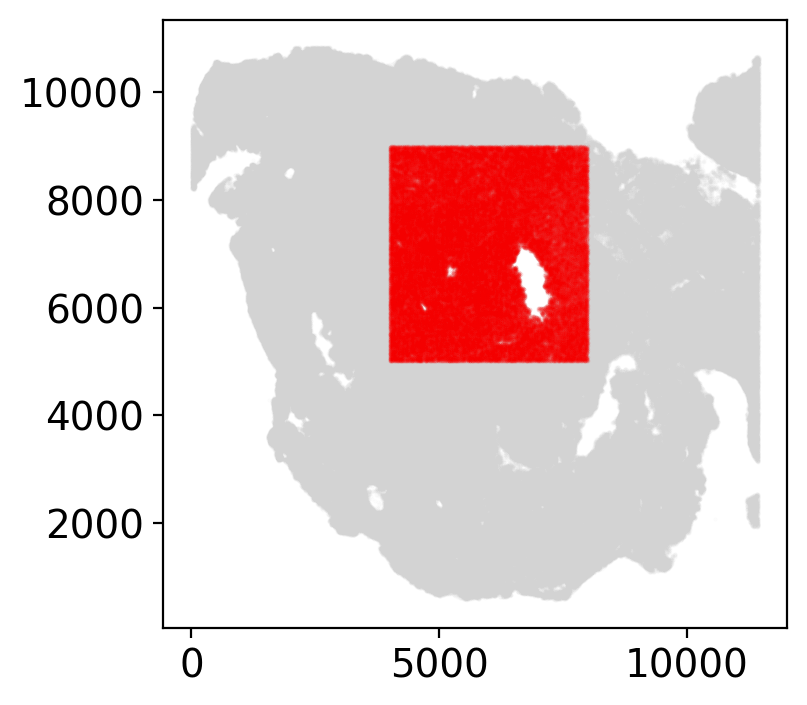

In [8]:
# read in xenium
avis = sc.read_10x_h5('/home/dchen2/LITERATURE/XENIUM_HUMAN_GBM/cell_feature_matrix.h5')
avis.var_names = avis.var_names.astype(str)
avis.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(avis, min_counts=100)
# normalize the data
sc.pp.normalize_total(avis, target_sum=1e6)
sc.pp.log1p(avis)
# read in the spatial
df = pd.read_csv('/home/dchen2/LITERATURE/XENIUM_HUMAN_GBM/cells.csv.gz', index_col=0)
df = df.loc[avis.obs.index]
# view the tissue and choose a specific area to focus on
fig, ax = plt.subplots()
ax.grid(False)
ax.scatter(df['x_centroid'], df['y_centroid'], s=0.1, alpha=0.1, color='lightgray')
mask = (df['x_centroid'] < 8000) & (df['x_centroid'] > 4000)
mask = mask & (df['y_centroid'] < 9000) & (df['y_centroid'] > 5000)
ax.scatter(df.loc[mask, 'x_centroid'], df.loc[mask, 'y_centroid'], s=0.1, alpha=0.1, color='r')

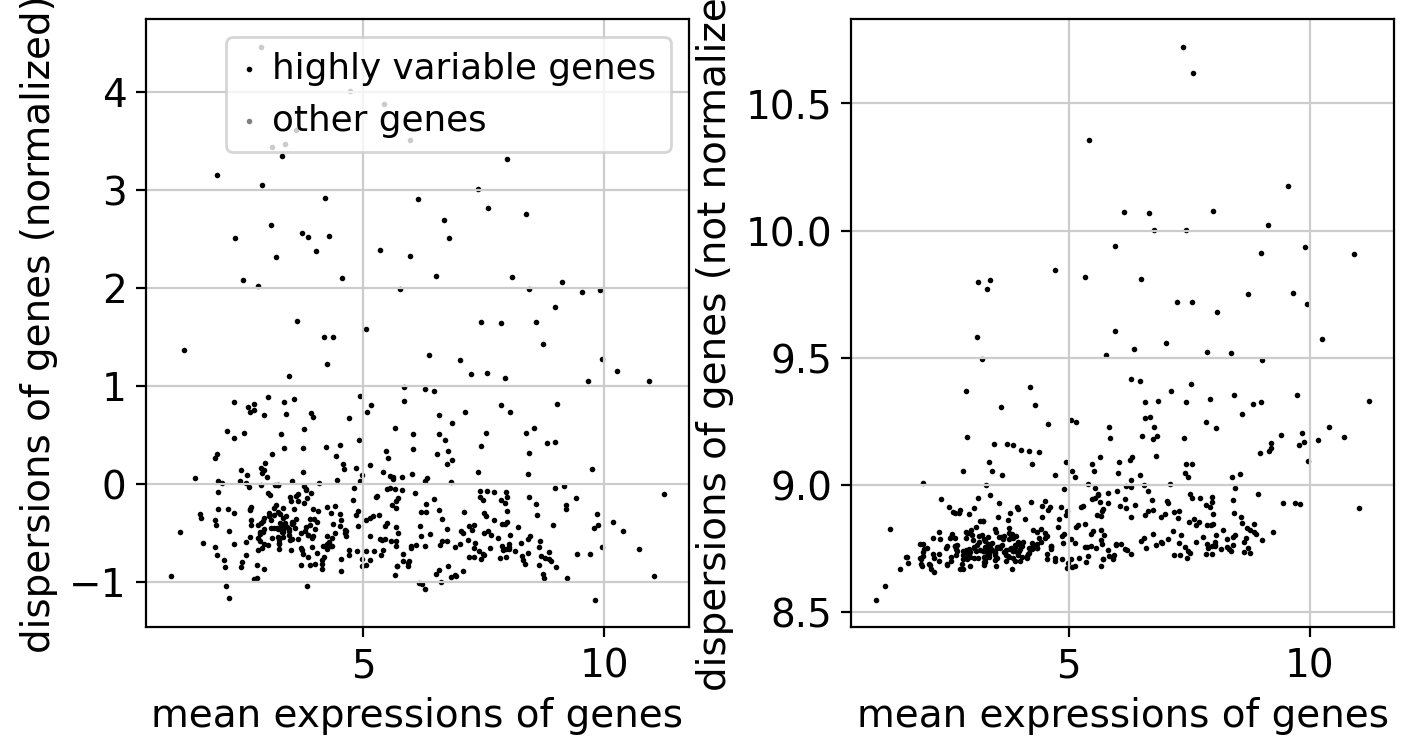

there are 480 hvgs


In [9]:
# add spatial and subset
avis.obsm['spatial'] = df.loc[avis.obs.index, ['x_centroid','y_centroid']].values
avis = avis[mask].copy()
# compute PCA for the spatial dataset using HVGs
avis.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(avis, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=avis.shape[1])
sc.pl.highly_variable_genes(avis)
# report how many HVGs we're going to use
print('there are', avis.var['highly_variable'].sum(), 'hvgs')

In [10]:
from scipy.spatial.distance import pdist, squareform
# create a gene subset for testing
genes = avis.var_names[avis.var['highly_variable']].tolist()
# define the parameters of the model
n_genes = len(genes)
learning_rate = 5e-2
n_neighbors = 6
zmft_scalar = 1e-1
seed = 0
epochs = 100

import time
# save the data
avis_storage = avis.copy()
# compute global distances
distances = squareform(pdist(df.loc[avis.obs.index, ['x_centroid','y_centroid']]))
distances = pd.DataFrame(distances, index=avis.obs.index, columns=avis.obs.index)

In [11]:
# check out the shape of the item
avis_storage.shape

(112081, 480)

In [12]:
# derive the statistics
df_stat = pd.DataFrame(columns=['device','n_cells','seed','duration'])
for device in ['cpu','cuda']:
    for n_cells in [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]:
        for seed in range(5):
            # set the seed
            np.random.seed(seed)
            # decide on the cells to analyze
            cell = np.random.choice(avis.obs.index, size=1, replace=False)[0]
            cells = distances.loc[cell, distances.columns].sort_values().index[:n_cells]
            # subset accordingly
            avis = avis_storage[cells, genes].copy()
            # retrieve positions from the data # only needed for simcomen later
            pos = torch.from_numpy(df.loc[avis.obs.index, ['x_centroid','y_centroid']].values)
            # convert the gene expression data to numpy
            x = torch.from_numpy(avis[:, genes].X.todense())
            # sphere normalize the data (just in case)
            norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
            assert (norm_factor > 0).all()
            x = torch.div(x, norm_factor)
            # compute the distances
            distances_ = distances.loc[avis.obs.index, avis.obs.index]
            # compute the edges as two cell widths apart so 30µm
            edge_index = torch.from_numpy(np.array(np.where((distances_ < 30)&(distances_ != 0))))
            avis.obs['sample'] = 'sample'
            avis.write_h5ad('data/avis.h5')
            # instantiate the model, input and output will be the same
            loader = get_dataset_loaders('data/avis.h5', 'sample', 6, device, True,)
            model = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
            input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
            input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
            model.set_g2g(torch.from_numpy(input_g2g))
            model.set_g2g_intra(torch.from_numpy(input_g2g))
            model.to(device)
            start_time = time.time()
            losses = train(epochs, learning_rate, model, loader, zmft_scalar=zmft_scalar, seed=1, device=device)
            duration = time.time() - start_time
            df_stat.loc[df_stat.shape[0]] = device, n_cells, seed, duration

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[100, 480], edge_index=[2, 1574], y=[1], pos=[100, 2], batch=[100], ptr=[2])



100%|█████████████████████████████████████████| 100/100 [00:02<00:00, 37.79it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[100, 480], edge_index=[2, 1550], y=[1], pos=[100, 2], batch=[100], ptr=[2])



100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 69.91it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[100, 480], edge_index=[2, 1668], y=[1], pos=[100, 2], batch=[100], ptr=[2])



...

Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[20000, 480], edge_index=[2, 375040], y=[1], pos=[20000, 2], batch=[20000], ptr=[2])



100%|█████████████████████████████████████████| 100/100 [00:30<00:00,  3.27it/s]


Step 1
=====
Number of graphs in the current batch: 1
DataBatch(x=[50000, 480], edge_index=[2, 970952], y=[1], pos=[50000, 2], batch=[50000], ptr=[2])



  1%|▍                                          | 1/100 [00:03<06:16,  3.81s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 9.31 GiB. GPU 0 has a total capacity of 10.91 GiB of which 800.06 MiB is free. Including non-PyTorch memory, this process has 10.13 GiB memory in use. Of the allocated memory 420.92 MiB is allocated by PyTorch, and 9.55 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

/loc/scratch/8916647/ipykernel_10388/252685384.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_10388/252685384.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_10388/252685384.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])


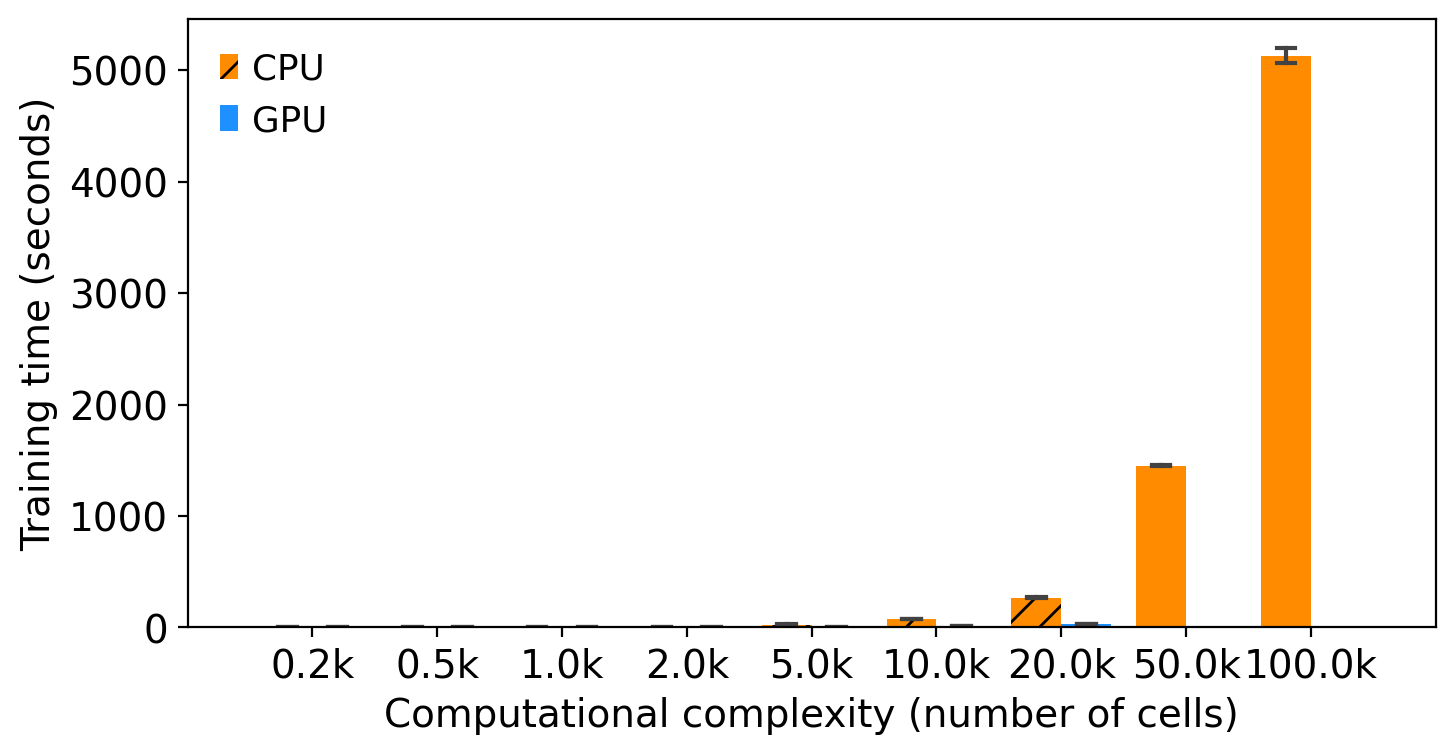

In [17]:
# show the values
fig, ax = plt.subplots(figsize=[8, 4]); ax.grid(False)
data = df_stat.loc[df_stat['n_cells'] >= 200].copy(); data['n_cells'] /= 1000
sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
            saturation=1, palette=['darkorange','dodgerblue'], hue_order=['cpu','cuda'])
ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])
ax.set_xlim(-1, 9)
ax.set_xlabel('Computational complexity (number of cells)')
ax.set_ylabel('Training time (seconds)')
for child in ax.get_children()[:7]:
    child.set_hatch('//')
ax.legend(frameon=False)
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[0].get_children()[1]\
.get_children()[0].set_text('CPU')
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[1].get_children()[1]\
.get_children()[0].set_text('GPU')
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[0].get_children()[0]\
.get_children()[0].set_hatch('//')

/loc/scratch/8916647/ipykernel_27688/646873962.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_27688/646873962.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_27688/646873962.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])


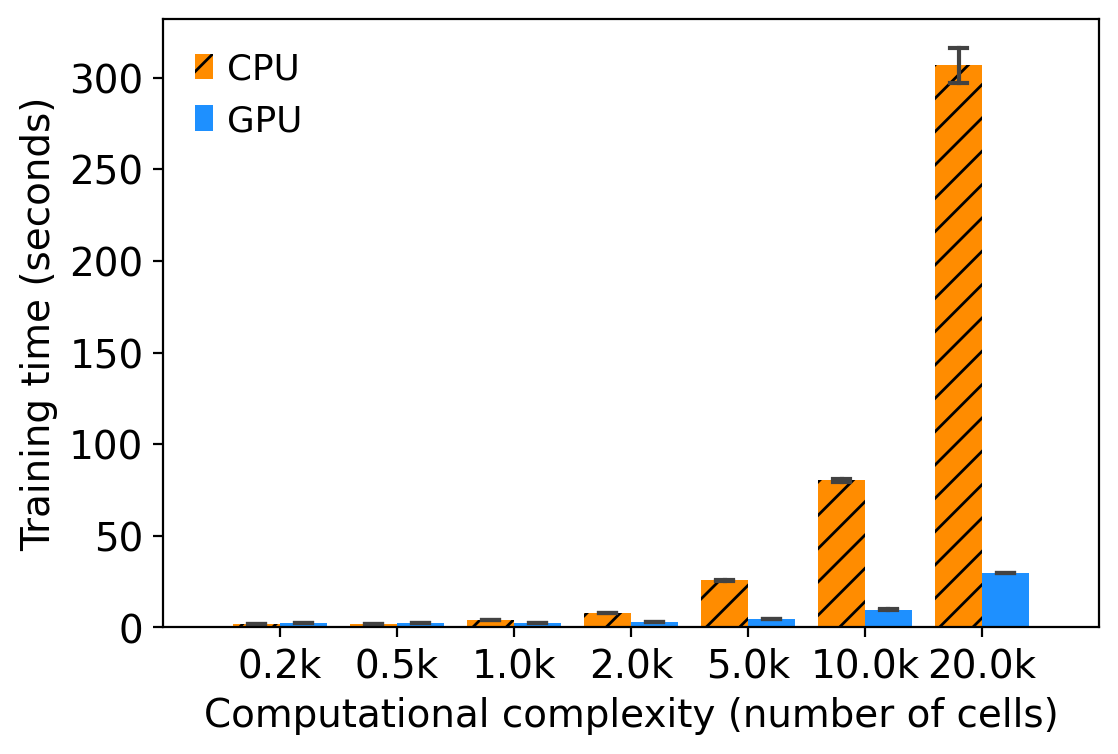

In [ ]:
# show the values
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
data = df_stat.loc[df_stat['n_cells'] >= 200].copy(); data['n_cells'] /= 1000
sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
            saturation=1, palette=['darkorange','dodgerblue'], hue_order=['cpu','cuda'])
ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])
ax.set_xlim(-1, 7)
ax.set_xlabel('Computational complexity (number of cells)')
ax.set_ylabel('Training time (seconds)')
for child in ax.get_children()[:7]:
    child.set_hatch('//')
ax.legend(frameon=False)
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[0].get_children()[1]\
.get_children()[0].set_text('CPU')
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[1].get_children()[1]\
.get_children()[0].set_text('GPU')
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[0].get_children()[0]\
.get_children()[0].set_hatch('//')

In [19]:
df_stat.to_csv('tmp.csv')

In [21]:
df_stat = df_stat.loc[df_stat['n_cells'] <= 20000]

/loc/scratch/8916647/ipykernel_10388/646873962.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_10388/646873962.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
/loc/scratch/8916647/ipykernel_10388/646873962.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])


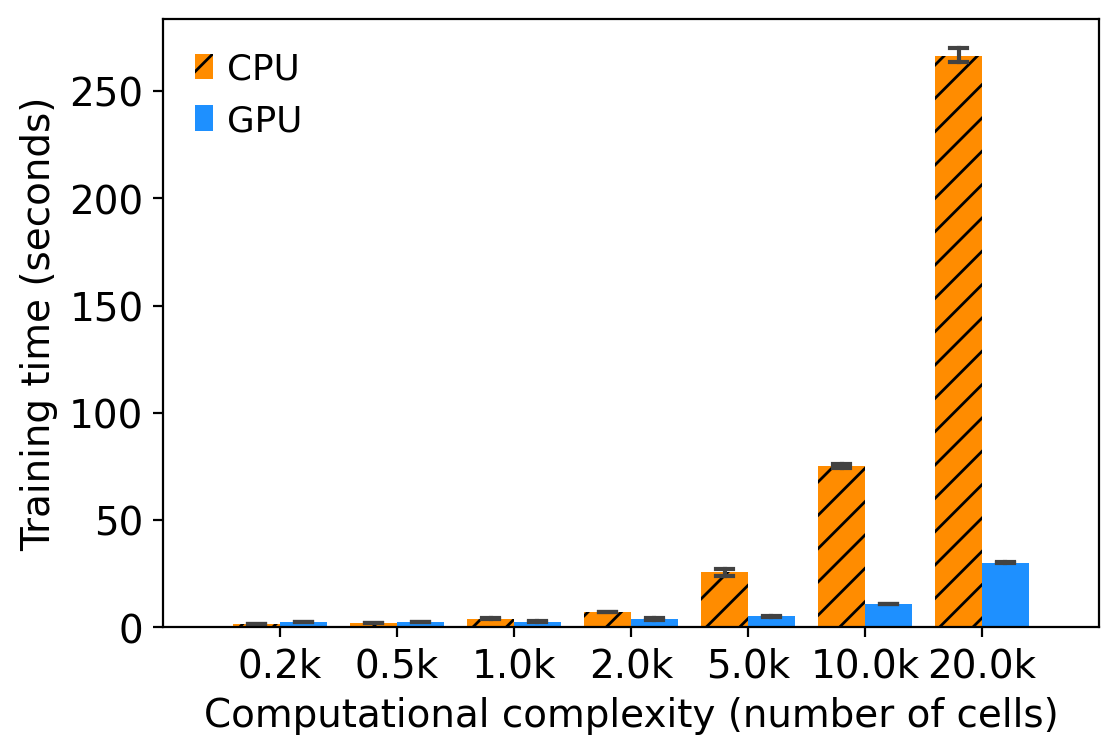

In [22]:
# show the values
fig, ax = plt.subplots(figsize=[6, 4]); ax.grid(False)
data = df_stat.loc[df_stat['n_cells'] >= 200].copy(); data['n_cells'] /= 1000
sns.barplot(x='n_cells', y='duration', hue='device', data=data, ci=68, errwidth=1.5, capsize=0.3,
            saturation=1, palette=['darkorange','dodgerblue'], hue_order=['cpu','cuda'])
ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])
ax.set_xlim(-1, 7)
ax.set_xlabel('Computational complexity (number of cells)')
ax.set_ylabel('Training time (seconds)')
for child in ax.get_children()[:7]:
    child.set_hatch('//')
ax.legend(frameon=False)
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[0].get_children()[1]\
.get_children()[0].set_text('CPU')
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[1].get_children()[1]\
.get_children()[0].set_text('GPU')
ax.get_children()[-2].get_children()[0].get_children()[1].get_children()[0].get_children()[0].get_children()[0]\
.get_children()[0].set_hatch('//')

In [26]:
df_agg = df_stat.groupby(['device','n_cells']).mean().reset_index().\
pivot_table(index='n_cells', columns='device', values='duration')

1    20.24568
2     2.81833
dtype: float64


/loc/scratch/8916647/ipykernel_10388/1853237684.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])


(-0.895, 20.995)

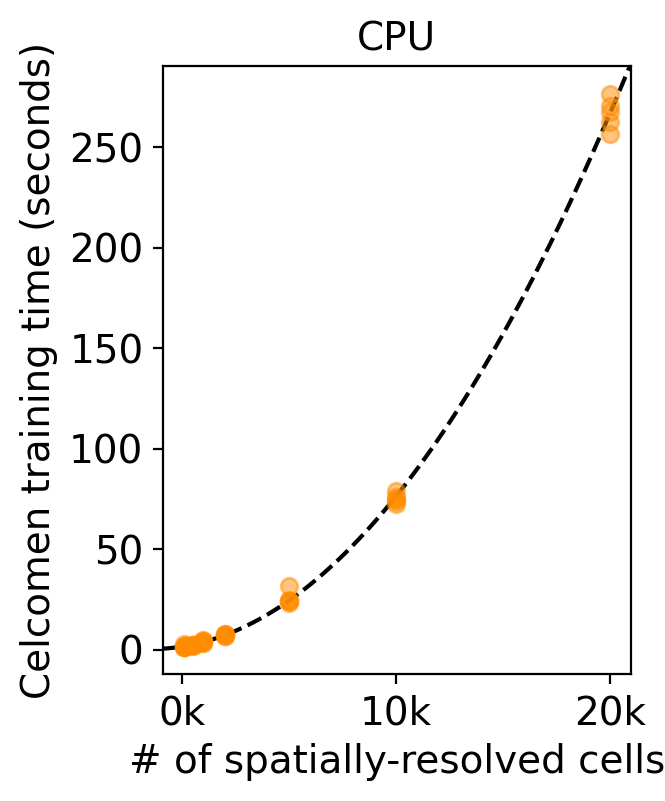

In [93]:
# grab the relevant data
mask = df_stat['device'] == 'cpu'
xs, ys = df_stat.loc[mask, 'n_cells'] / 1e3, df_stat.loc[mask, 'duration']
# report on the RMSEs
rmses = pd.Series()
for deg in range(1, 2+1):
    model = np.polynomial.Polynomial(deg)
    model = model.fit(xs, ys, deg)
    rmse = np.sqrt(np.mean((ys - model(xs)) ** 2))
    rmses.loc[deg] = rmse
print(rmses)
# plot the model and data
fig, ax = plt.subplots(figsize=[3, 4]); ax.grid(False)
ax.scatter(xs, ys, color='darkorange', alpha=0.5)
xlim, ylim = ax.get_xlim(), ax.get_ylim()
xl, yl = model.linspace(domain=xlim)
ax.plot(xl, yl, color='k', linestyle='--', zorder=0)
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])
ax.set_xlabel('# of spatially-resolved cells')
ax.set_ylabel('Celcomen training time (seconds)')
ax.set_title('CPU')
ax.set_xlim(*xlim)

In [95]:
model(1000) / 60

9663.346998883551

1    1.967715
2    0.473275
dtype: float64


/loc/scratch/8916647/ipykernel_10388/4135612864.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])


(-12.333917832374574, 290.15038273334505)

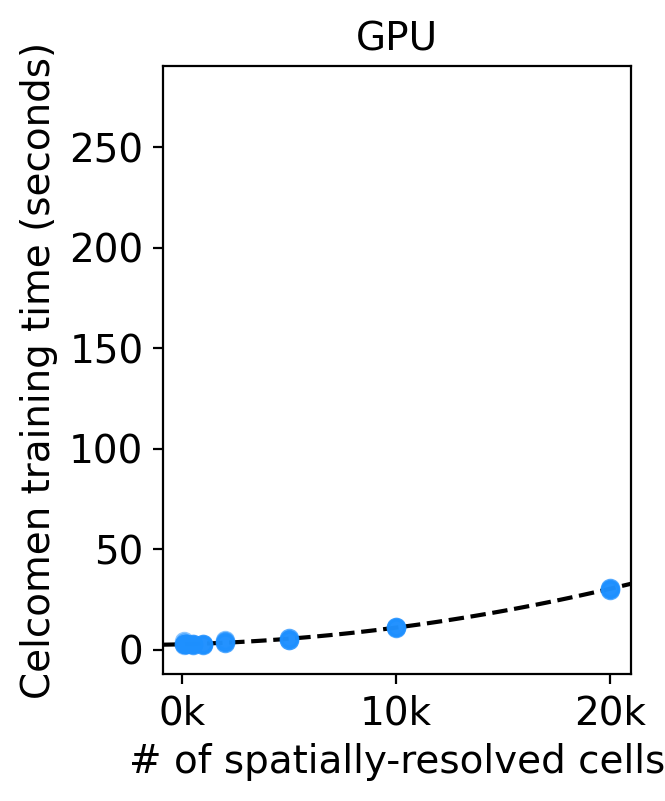

In [96]:
# grab the relevant data
mask = df_stat['device'] == 'cuda'
xs, ys = df_stat.loc[mask, 'n_cells'] / 1e3, df_stat.loc[mask, 'duration']
# report on the RMSEs
rmses = pd.Series()
for deg in range(1, 2+1):
    model = np.polynomial.Polynomial(deg)
    model = model.fit(xs, ys, deg)
    rmse = np.sqrt(np.mean((ys - model(xs)) ** 2))
    rmses.loc[deg] = rmse
print(rmses)
# plot the model and data
fig, ax = plt.subplots(figsize=[3, 4]); ax.grid(False)
ax.scatter(xs, ys, color='dodgerblue', alpha=0.5)
xlim = ax.get_xlim()
xl, yl = model.linspace(domain=xlim)
ax.plot(xl, yl, color='k', linestyle='--', zorder=0)
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xticklabels([x.get_text() + 'k' for x in ax.get_xticklabels()])
ax.set_xlabel('# of spatially-resolved cells')
ax.set_ylabel('Celcomen training time (seconds)')
ax.set_title('GPU')
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

In [97]:
model(1000) / 60

922.5886533296646